In [32]:
# Import cell, ensure this runs first!
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

In [ ]:
DATA_PATH = "../../data/used/"

# Loading the kaggle data
KAGGLE_SUFFIX = ".us.txt"   # All the kaggle-gathered data ends with this file type, convenience variable.
BIL  = pd.read_csv(os.path.join(DATA_PATH, "bil" + KAGGLE_SUFFIX), parse_dates=["Date"])
BND  = pd.read_csv(os.path.join(DATA_PATH, "bnd" + KAGGLE_SUFFIX), parse_dates=["Date"])
EFA  = pd.read_csv(os.path.join(DATA_PATH, "efa" + KAGGLE_SUFFIX), parse_dates=["Date"])
RWR  = pd.read_csv(os.path.join(DATA_PATH, "rwr" + KAGGLE_SUFFIX), parse_dates=["Date"])
SPY  = pd.read_csv(os.path.join(DATA_PATH, "spy" + KAGGLE_SUFFIX), parse_dates=["Date"])
VNQ  = pd.read_csv(os.path.join(DATA_PATH, "vnq" + KAGGLE_SUFFIX), parse_dates=["Date"])
VTI  = pd.read_csv(os.path.join(DATA_PATH, "vti" + KAGGLE_SUFFIX), parse_dates=["Date"])
VXUS = pd.read_csv(os.path.join(DATA_PATH, "vxus" + KAGGLE_SUFFIX), parse_dates=["Date"]) # Kaggle data only has ~1700 rows

# ============== Loading other data sources ==============
# From Federal Reserve Bank of St. Louis, https://fred.stlouisfed.org/series/DTB3
DTB3 = pd.read_csv(os.path.join(DATA_PATH, "DTB3.csv"), parse_dates=["observation_date"])
DTB3.rename(columns={"observation_date": "Date"}, inplace=True)

# From fetch_yahoo.py script
# yfinance data has odd formatting, need to reformat before parsing date column.
VBMFX = pd.read_csv(os.path.join(DATA_PATH, "vbmfx.csv"), header=None)

col_names = VBMFX.iloc[0].tolist()

col_names[0] = "Date"
tckr = VBMFX.iloc[1, 1]

VBMFX = VBMFX.iloc[3:].copy()
VBMFX.columns = col_names

VBMFX["Date"] = pd.to_datetime(VBMFX["Date"])

BIL.set_index("Date", inplace=True)
BND.set_index("Date", inplace=True)
DTB3.set_index("Date", inplace=True)
EFA.set_index("Date", inplace=True)
RWR.set_index("Date", inplace=True)
SPY.set_index("Date", inplace=True)
VBMFX.set_index("Date", inplace=True)
VNQ.set_index("Date", inplace=True)
VTI.set_index("Date", inplace=True)
VXUS.set_index("Date", inplace=True)

After some initial exploration, I found that some of the kaggle data had relatively few observations (~1700) while other data points had many observations (>3000). For now, I will continue exploring the data set as is, because my yahoo data is rate-limited, but long term I would like to pull down more data from yahoo finance, contrast it with my initial dataset, and potentially centralize my dataset around yahoo finance, for a longer horizon. For now, my Markowitz Optimization model will be highly tuned towards modern economic patterns.

In [34]:
print(f"Total NA in BIL  : {BIL.isna().sum()}")
print(f"Total NA in BND  : {BND.isna().sum()}")
print(f"Total NA in DTB3 : {DTB3.isna().sum()}")
print(f"Total NA in EFA  : {EFA.isna().sum()}")
print(f"Total NA in RWR  : {RWR.isna().sum()}")
print(f"Total NA in SPY  : {SPY.isna().sum()}")
print(f"Total NA in VBMFX: {VBMFX.isna().sum()}")
print(f"Total NA in VNQ  : {VNQ.isna().sum()}")
print(f"Total NA in VTI  : {VTI.isna().sum()}")
print(f"Total NA in VXUS : {VXUS.isna().sum()}")

Total NA in BIL  : Open       0
High       0
Low        0
Close      0
Volume     0
OpenInt    0
dtype: int64
Total NA in BND  : Open       0
High       0
Low        0
Close      0
Volume     0
OpenInt    0
dtype: int64
Total NA in DTB3 : DTB3    795
dtype: int64
Total NA in EFA  : Open       0
High       0
Low        0
Close      0
Volume     0
OpenInt    0
dtype: int64
Total NA in RWR  : Open       0
High       0
Low        0
Close      0
Volume     0
OpenInt    0
dtype: int64
Total NA in SPY  : Open       0
High       0
Low        0
Close      0
Volume     0
OpenInt    0
dtype: int64
Total NA in VBMFX: Close     1
High      1
Low       1
Open      1
Volume    0
dtype: int64
Total NA in VNQ  : Open       0
High       0
Low        0
Close      0
Volume     0
OpenInt    0
dtype: int64
Total NA in VTI  : Open       0
High       0
Low        0
Close      0
Volume     0
OpenInt    0
dtype: int64
Total NA in VXUS : Open       0
High       0
Low        0
Close      0
Volume     0
OpenInt   

Only the DTB3 data set has missing data

In [35]:
close_vals =  [
                BIL["Close"]  , BND["Close"],
                DTB3["DTB3"]  , EFA["Close"],
                RWR["Close"]  , SPY["Close"],
                VBMFX["Close"], VNQ["Close"],
                VTI["Close"]  , VXUS["Close"],
              ]

col_names = ["BIL", "BND", "DTB3", "EFA", "RWR", "SPY", "VBMFX", "VNQ", "VTI", "VXUS"]
combined = pd.concat(close_vals, axis=1)
combined.columns = col_names

combined.sort_index(inplace=True)
cleaned = combined.dropna(how="any")  # Find the max period where no feature has an NA

cleaned[col_names] = cleaned[col_names].apply(pd.to_numeric)

print(cleaned.isna().sum())

BIL      0
BND      0
DTB3     0
EFA      0
RWR      0
SPY      0
VBMFX    0
VNQ      0
VTI      0
VXUS     0
dtype: int64


C:\Users\drewm\AppData\Local\Temp\ipykernel_28988\538906098.py:10: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined = pd.concat(close_vals, axis=1)


It looks like our dataset has a complete and consistent daily close price for each of our selected stocks, for a period stretching from  2011-02-01 to 2017-11-10, roughly 6.5 years. My goal of Markowitz Optimization can be significantly skewed by time, policies such as ZIRP can significantly change the relationships between features studied in this project, altering the mathematical optimum. As such, it is ideal for this project to collect further data enabling a window closer to the modern day, but this is sufficient for now.

`VXUS`, `BIL`, and `BND` have the smallest number of observations (`VXUS` ~1700, `BIL/BND` ~2600)

The `cleaned` dataframe now contains date-aligned, frequency-matched, gapless data for all of the features used in this project.

Plotting BIL, mean: 1.6958540069769906e-06
Plotting BND, mean: 0.00012132987296043227
Plotting EFA, mean: 0.00025329133803051016
Plotting RWR, mean: 0.0004339231627383106
Plotting SPY, mean: 0.0005238639254244714
Plotting VBMFX, mean: 0.00013340454156145112
Plotting VNQ, mean: 0.0004493609774202916
Plotting VTI, mean: 0.0005162984562002659
Plotting VXUS, mean: 0.00022373224834099567
Plotting DTB3, mean: 7.895279323850753e-06


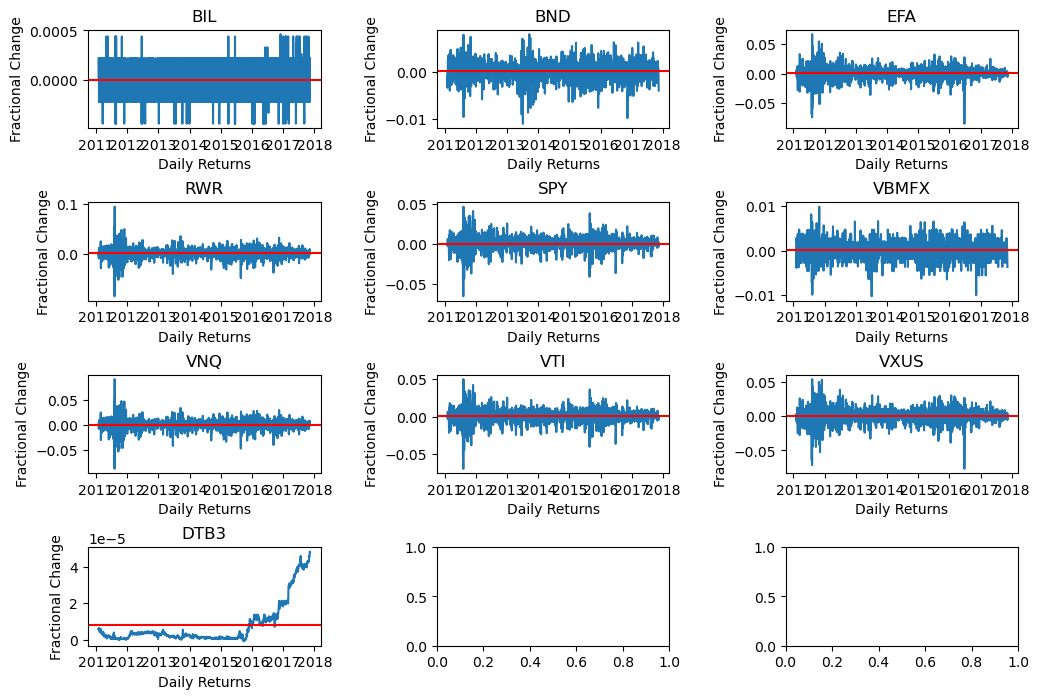

In [36]:
tckrs = cleaned.loc[:, cleaned.columns != "DTB3"]

ret = tckrs.pct_change()

dtb3_daily = (cleaned["DTB3"] / 100) / 252
ret = ret.join(dtb3_daily.rename("DTB3"))

fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(12, 8))
fig.subplots_adjust(hspace=.75, wspace=0.5)

means = []
for idx, col in enumerate(list(ret.columns)):
  mean = ret[col].mean()
  means.append(mean)

  print(f"Plotting {col}, mean: {mean}")

  i = idx // 3
  j = idx % 3

  ax[i, j].plot(ret.index, ret[col])

  ax[i, j].axhline(mean, color="red")

  ax[i, j].set(xlabel='Daily Returns', ylabel='Fractional Change',
         title=str(col))


In [37]:
"""
- Originally ran into errors with treating dtb3 incorrectly.
- This section explored the occurrence of NAs in the data set.

Kept for posterity but not particularly important to the finalized EDA.
"""


# s = cleaned["DTB3"]
# r = ret["DTB3"]

# print("cleaned dtb3 dtype:", s.dtype)
# print("ret dtb3 dtype:", r.dtype)

# print("cleaned dtb3 NaNs:", s.isna().sum(), "out of", len(s))
# print("ret dtb3 NaNs:", r.isna().sum(), "out of", len(r))

# print("ret dtb3 non-NaN count:", r.notna().sum())
# print("ret dtb3 unique (cleaned, first 10):", pd.Series(s).astype(str).unique()[:10])

# print("ret dtb3 head:\n", r.head(10))
# print("ret dtb3 describe:\n", r.describe())


'\n- Originally ran into errors with treating dtb3 incorrectly.\n- This section explored the occurrence of NAs in the data set.\n\nKept for posterity but not particularly important to the finalized EDA.\n'

In [38]:
summary = pd.DataFrame({
    "mean": ret.mean(),
    "std": ret.std(),
    "skew": ret.skew(),
    "kurtosis": ret.kurtosis(),
    "min": ret.min(),
    "max": ret.max()
})

summary.sort_values("std", ascending=False)
print(summary)

           mean       std      skew  kurtosis           min       max
BIL    0.000002  0.000167 -0.063243 -0.061841 -4.402377e-04  0.000462
BND    0.000121  0.002121 -0.352764  1.786751 -1.110347e-02  0.008001
EFA    0.000253  0.011369 -0.653330  6.472766 -8.600458e-02  0.067372
RWR    0.000434  0.011037 -0.216708  7.513037 -8.594924e-02  0.094419
SPY    0.000524  0.008995 -0.460697  5.050161 -6.527133e-02  0.046526
VBMFX  0.000133  0.002203 -0.141872  1.032390 -1.030883e-02  0.009898
VNQ    0.000449  0.010828 -0.272111  7.537702 -8.687709e-02  0.091062
VTI    0.000516  0.009244 -0.477747  5.223059 -6.932624e-02  0.050052
VXUS   0.000224  0.011087 -0.557023  4.903493 -7.652879e-02  0.053403
DTB3   0.000008  0.000012  2.001548  2.909456 -7.936508e-07  0.000048


### Analysis

Markowitz optimization assumes that means exist and are realistic, variance is finite, covariance is meaningful, and that the distribution of returns is normal.

The worst drawdowns are around $-6\%$ to $-8\%$, while the best days are around $5\%$ to $9\%$, matching stats from 2011-2017.

A numeric analysis of the data finds variance groupings that align with expectation:

`EFA`, `RWR`, `VNQ`, `VXUS` ⟶ ~0.011 ⟶ Equities, real estate, international ETFs; higher volatility
`SPY`, `VTI` ⟶ ~0.09 ⟶ ETFs, exposure to more stable market; high volatility but lower than international equities or real estate.
`BND`, `VBMFX` ⟶ ~0.002 ⟶ Broad, long term exposure to historical US market.
`BIL` ⟶ ~0.0002 ⟶ Significantly lower volatility than direct equity exposure, but higher voltatility than the treasury bill rate.
`DTB3` ⟶ 0.000012 ⟶ Low volatility reflects ZIRP period

All of the skew values reflect normal crash asymmetry, market down-turns tend to be sharper, faster, and more volatile than equivalent up-turns, explaining why the skews are negative. Because `DTB3` was held near 0 for a significant portion of the data range before gradually increasing, this causes a significant right-skew.

In financial asset distributions, the amplitude of tails implies the probability of extreme or "black swan" events. Kurtosis is a common way of defining the thickness of a distributions tails. An idealized portfolio generated through Markowitz optimization over data with fat tails carries a higher implicit risk of sudden, extreme value changes. Since the goal of this portfolio optimizer is to limit risk exposure at a given level of portfolio growth, we prefer a distribution with minimal kurtosis and thin tails.

The distribution of kurtosis in my data set ranges from near 0 for cash, to 1-3 for bonds and traditionally low risk assets, to 5-7 for equities and international markets, which align with expectation. Common kurtosis values for equities range from 4 to 10 or larger.

Crucially, a single feature with comparatively large volatility would dominate my Markowitz optimization, no single feature in the dataset dominates volatility.

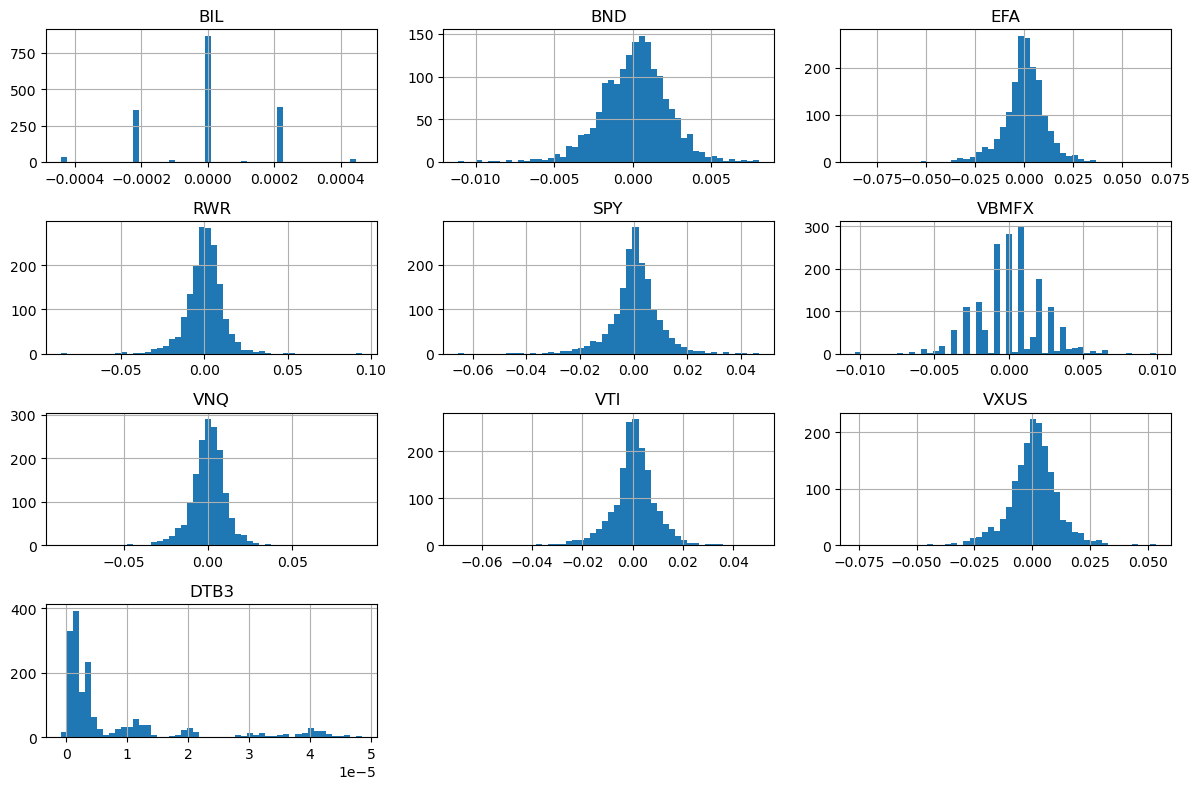

In [39]:
ret.hist(bins=50, figsize=(12, 8))
plt.tight_layout()

Broadly, the distribution of returns from each feature in my data set is normal. `BIL` reflects a discrete, almost perfectly normal distribution because it is effectively a short-duration, rolling instrument with low volatility and discrete changes.

`DTB3` shows an extremely multi-modal, non-normal distribution, with the primary peak at 0. This aligns with the ZIRP period included in our data set. The 3-month treasury bill rate is never negative, so the largest peak at 0 is not normally distributed, however the smaller peaks in the right-skew appear to be normal.

Excepting `BIL` and `DTB3`, our features display sharply normal distributions with minimal tails, centered near 0, which aligns with expectations for daily returns in the stock market.

Markowitz portfolio optimization works by leveraging correlations between equity positions to minimize risk at a given level of growth. It is crucial that we examine the correlation and covariance of our features, since high correlation will provide the model with little information to optimize.

In [40]:
corr = ret.corr() # Get correlation matrix
corr

,BIL,BND,EFA,RWR,SPY,VBMFX,VNQ,VTI,VXUS,DTB3
BIL,1.000000,0.014599,-0.002242,-0.043460,-0.021515,0.033545,-0.041391,-0.024013,-0.010062,0.056578
BND,0.014599,1.000000,-0.275589,-0.014287,-0.322394,0.899269,-0.005956,-0.319919,-0.250709,-0.012092
EFA,-0.002242,-0.275589,1.000000,0.659315,0.882513,-0.345015,0.661038,0.879557,0.979265,0.020049
RWR,-0.043460,-0.014287,0.659315,1.000000,0.723362,-0.072249,0.996064,0.731553,0.667695,-0.006161
SPY,-0.021515,-0.322394,0.882513,0.723362,1.000000,-0.398433,0.727475,0.995911,0.887082,0.009124
VBMFX,0.033545,0.899269,-0.345015,-0.072249,-0.398433,1.000000,-0.063374,-0.395692,-0.323101,-0.014757
VNQ,-0.041391,-0.005956,0.661038,0.996064,0.727475,-0.063374,1.000000,0.736308,0.669302,-0.004148
VTI,-0.024013,-0.319919,0.879557,0.731553,0.995911,-0.395692,0.736308,1.000000,0.886108,0.009172
VXUS,-0.010062,-0.250709,0.979265,0.667695,0.887082,-0.323101,0.669302,0.886108,1.000000,0.025122
DTB3,0.056578,-0.012092,0.020049,-0.006161,0.009124,-0.014757,-0.004148,0.009172,0.025122,1.000000


In [41]:
cov = ret.cov() # Get covariance matrix
cov

,BIL,BND,EFA,RWR,SPY,VBMFX,VNQ,VTI,VXUS,DTB3
BIL,2.793571e-08,5.175220e-09,-4.260304e-09,-8.016762e-08,-3.234783e-08,1.235412e-08,-7.491210e-08,-3.710089e-08,-1.864644e-08,1.088803e-10
BND,5.175220e-09,4.498501e-06,-6.645522e-06,-3.344384e-07,-6.150873e-06,4.202748e-06,-1.367888e-07,-6.272402e-06,-5.895416e-06,-2.952882e-10
EFA,-4.260304e-09,-6.645522e-06,1.292607e-04,8.272944e-05,9.025483e-05,-8.643320e-06,8.138052e-05,9.243932e-05,1.234365e-04,2.624513e-09
RWR,-8.016762e-08,-3.344384e-07,8.272944e-05,1.218056e-04,7.181345e-05,-1.757016e-06,1.190371e-04,7.463439e-05,8.170007e-05,-7.828793e-10
SPY,-3.234783e-08,-6.150873e-06,9.025483e-05,7.181345e-05,8.091565e-05,-7.897357e-06,7.085904e-05,8.281258e-05,8.846886e-05,9.450155e-10
VBMFX,1.235412e-08,4.202748e-06,-8.643320e-06,-1.757016e-06,-7.897357e-06,4.855340e-06,-1.512098e-06,-8.059842e-06,-7.893286e-06,-3.743987e-10
VNQ,-7.491210e-08,-1.367888e-07,8.138052e-05,1.190371e-04,7.085904e-05,-1.512098e-06,1.172526e-04,7.370217e-05,8.035145e-05,-5.170977e-10
VTI,-3.710089e-08,-6.272402e-06,9.243932e-05,7.463439e-05,8.281258e-05,-8.059842e-06,7.370217e-05,8.545134e-05,9.081476e-05,9.762540e-10
VXUS,-1.864644e-08,-5.895416e-06,1.234365e-04,8.170007e-05,8.846886e-05,-7.893286e-06,8.035145e-05,9.081476e-05,1.229195e-04,3.206820e-09
DTB3,1.088803e-10,-2.952882e-10,2.624513e-09,-7.828793e-10,9.450155e-10,-3.743987e-10,-5.170977e-10,9.762540e-10,3.206820e-09,1.324911e-10


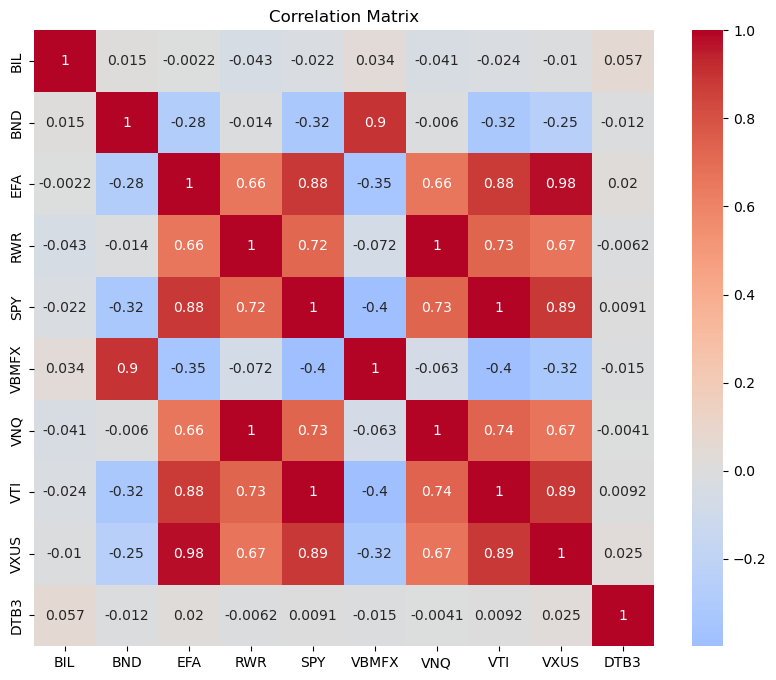

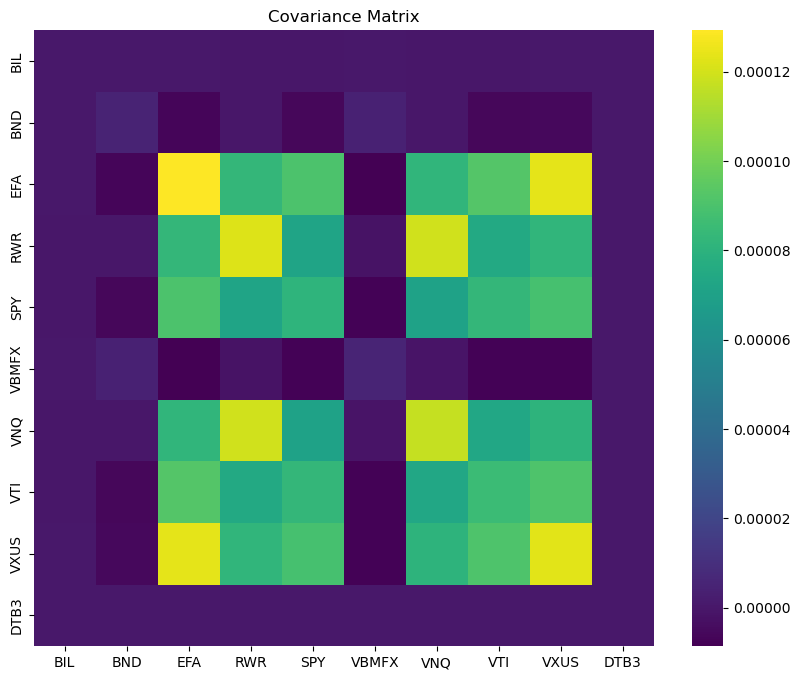

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(cov, cmap="viridis")
plt.title("Covariance Matrix")
plt.show()

These plots paint a daunting picture of our dataset, but the outcome is predictable. We collected 2 features for each defined category in this portfolio optimizer, logically 2 features describing the same underlying component should have high correlation.

While high correlation between features would be a problem in our final model, the final model will optimize across 5 asset-class representative features, where each feature is the average of the 2 real features collected to form it.

We should examine the correlations between these abstract features, since that is what the Markowitz optimization will analyze.

In [43]:
# Derive the average from each of the 2 stocks selected for each asset class.
us_equity = ret[["SPY", "VTI"]].mean(axis=1)
intl_equity = ret[["EFA", "VXUS"]].mean(axis=1)
bonds = ret[["BND", "VBMFX"]].mean(axis=1)
reits = ret[["VNQ", "RWR"]].mean(axis=1)
cash = ret[["BIL", "DTB3"]].mean(axis=1)

# Returns of the 5 'asset-class' representatives we've derived
ret5 = pd.concat([
    us_equity.rename("US_Equity"),
    intl_equity.rename("International"),
    bonds.rename("Bonds"),
    reits.rename("REITs"),
    cash.rename("Cash")
], axis=1)

In [44]:
import numpy as np

corr5 = ret5.corr()
cov5 = ret5.cov()
eigs = np.linalg.eigvalsh(cov5) #eigvalsh (not eigvals) because cov is symmetric

print("Eigenvalues:")
print(eigs)

print("Min eigenvalue:", eigs.min())
print("Max eigenvalue:", eigs.max())
print("Condition number:", eigs.max() / eigs.min())

Eigenvalues:
[7.03714576e-09 3.15554675e-06 1.05641971e-05 4.36345681e-05
 2.74129975e-04]
Min eigenvalue: 7.037145760059488e-09
Max eigenvalue: 0.00027412997486156356
Condition number: 38954.710362464655


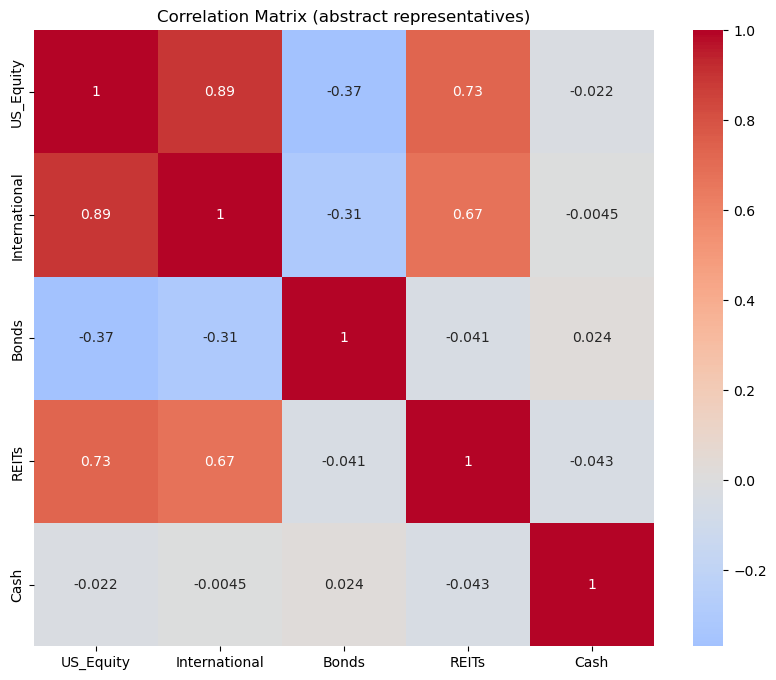

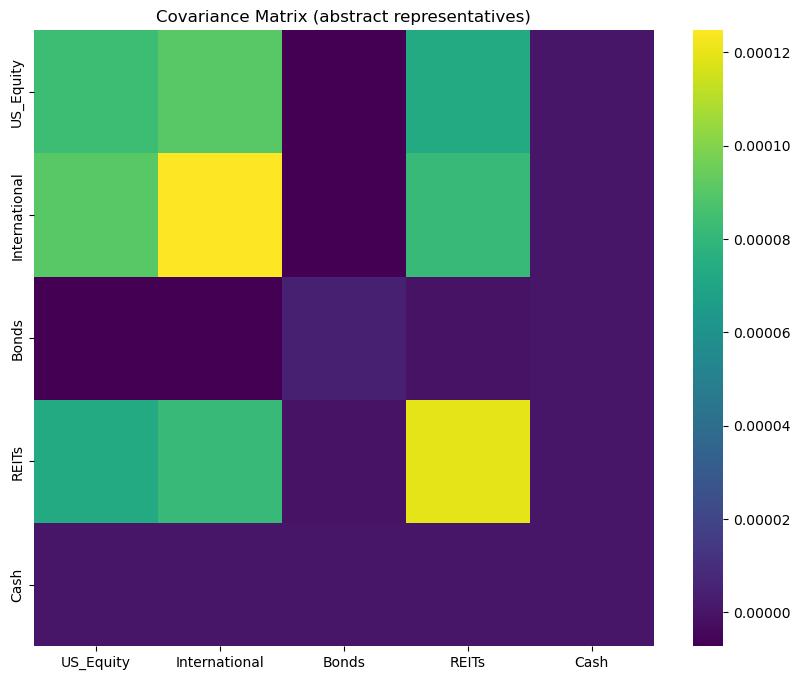

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(corr5, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (abstract representatives)")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(cov5, cmap="viridis")
plt.title("Covariance Matrix (abstract representatives)")
plt.show()

After combining our selected features into the 5 features that will be presented to the model, we identify a much better outlook for this data set to function in Markowitz optimization.

A condition number of 38,955 is relatively large and not ideal, and it implies that small errors in our dataset or modeling could amplify errors in outcome predicted by our model. However, financial assets often share common risk factors and are influenced at large scale by global features, so a low condition number is unrealistic to expect.

The existence of dominant global-scale features is further evidenced by the strong correlation between U.S. and International equities. Sharing a correlation of `0.89` both U.S. and international equities are likely dominated by shared underlying drivers, and a principal component would likely capture most of the shared variance between them.

Bonds provide meaningful diversification through moderate negative correlation with equities, providing benefits through covariance structure and enabling hedging behavior in our model. Cash exhibits near-zero covariance with other asset classes, providing diversification benefit through low variance rather than hedging behavior.

In [46]:
ret5.to_csv("daily_returns.csv")
cleaned.to_csv("cleaned.csv")